# Yelp Restaurant Sentiment Analysis

#### Yelp restoran yorumlarını kullanarak metin ön işleme, duygu skorlama, makine öğrenmesi ile sınıflandırma ve görselleştirme yapılmıştır.

<img src="https://yelparticles.wpengine.com/wp-content/uploads/2024/11/9-paseo-yelp-best-new-restaurants-1-1024x683.jpg" width="600"/>

### Import packages

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import Data

In [7]:
df = pd.read_csv("restaurant.csv")

### Exploratory Data Analysis

In [9]:
df.head()

,Unnamed: 0,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,2370338,_WTGv5XnA-qb_XD1D7Z0jg,6PgdGb3HrZdsfl2GiULo8w,RESDUcs7fIiihp38-d6_6g,5,0,1,0,After getting food poisoning at the Palms hote...,2012-12-04 03:10:18
1,2370357,JlNnsvMPLK_1-X2hwzK24w,IS9yw8P2uAPBX6FNLLX4KA,RESDUcs7fIiihp38-d6_6g,4,39,21,29,"""A feast worthy of Gods""\n\nBaccarnal Buffet i...",2014-01-17 00:50:50
2,2370373,hBkoWffORRb6aqKhC_Li2A,uZdFsE_aHbFBChgN6Xa8tw,RESDUcs7fIiihp38-d6_6g,4,1,1,1,The crab legs are better than the ones at Wick...,2015-06-08 18:03:09
3,2370411,rbkxvrgZg5kdCL2a66QYmA,8ZWJNAEWsymXDzKx3B0tTQ,RESDUcs7fIiihp38-d6_6g,1,0,0,0,Not worth it! Too salty food and expensive! Th...,2016-12-19 16:15:29
4,2370500,5tw_pedoHVi9bgeiBNsISg,E0sm4Ve7ifanFYeQMcV8Eg,RESDUcs7fIiihp38-d6_6g,5,0,0,0,I would give this infinite stars if I could. M...,2015-07-28 07:13:17


In [10]:
print("Veri setinde", df.shape[0], "satır ve", df.shape[1], "sütun var.")

Veri setinde 10417 satır ve 10 sütun var.


In [11]:
df=df[['stars','text']]

In [12]:
df.sample(3)

,stars,text
5985,4,SO MANY OPTIONS. The wait for dinner was a pai...
9312,5,What a way to start a quality Sunday brunch Bu...
5586,5,This is the best buffet in Vegas! I went durin...


In [13]:
# Yıldızlara göre Sayım ve oran hesapla
counts = df['stars'].value_counts().sort_index()
ratios = df['stars'].value_counts(normalize=True).sort_index().round(2)

In [14]:
print(counts,ratios)

stars
1    1056
2     917
3    1561
4    2636
5    4247
Name: count, dtype: int64 stars
1    0.10
2    0.09
3    0.15
4    0.25
5    0.41
Name: proportion, dtype: float64


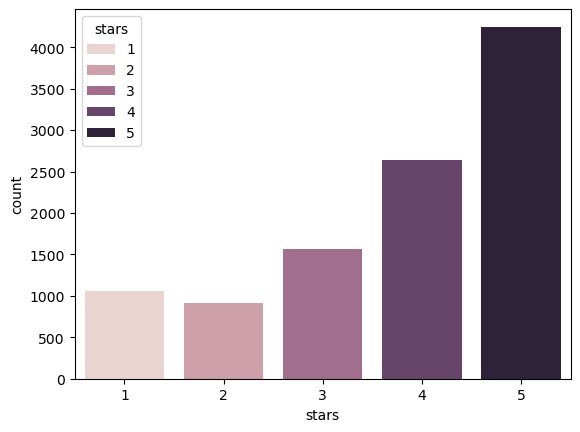

In [15]:
sns.countplot(x=df["stars"], hue=df["stars"]);

Adding Sentiment Features

In [17]:
df.loc[df['stars']==3,"sentiment"]="neutral"
df.loc[df['stars']<3,"sentiment"]="negative"
df.loc[df['stars']>3,"sentiment"]="positive"

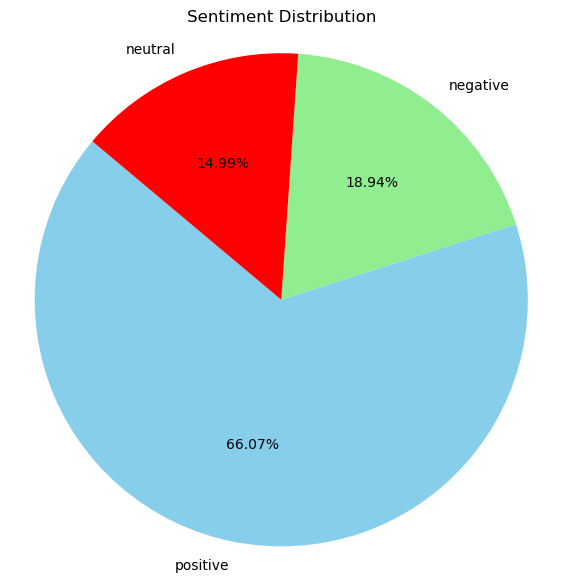

In [18]:
#Pie Chart
sentiment_counts = df['sentiment'].value_counts()

sentiment_percentages = (sentiment_counts / sentiment_counts.sum()) * 100

colors = ['skyblue', 'lightgreen', 'red']


plt.figure(figsize=(7, 7))
plt.pie(sentiment_percentages,
        labels=sentiment_percentages.index,
        autopct='%1.2f%%',
        startangle=140,
        colors=colors)
plt.title('Sentiment Distribution')
plt.axis('equal')  
plt.show()

Removing Characters

In [20]:
df["text"] = df["text"].str.lower() # Metindeki tüm kelimeler küçük harfe dönüştürülür
df["text"] = df["text"].str.replace(r'[^\w\s]', ' ', regex=True)  # metindeki noktalama işaretleri ve özel karakterler (harf, rakam ve boşluk dışındaki) kaldırılır
df["text"] = df["text"].str.replace(r'\d+', '', regex=True)        # metindeki tüm rakamlar  silinir
df["text"] = df["text"].str.replace(r'\n', ' ', regex=True)         # satır atlama (newline) karakterleri kaldırılır
df["text"] = df["text"].str.replace(r',\r', ' ', regex=True)        # virgül ve ardından gelen carriage return karakterleri silinir
df["text"] = df["text"].str.replace(r'\s+', ' ', regex=True).str.strip() # fazladan boşlukları tek boşluk haline getir

In [21]:
df.sample(5)

,stars,text,sentiment
2992,1,worse buffet i ever had in vegas got so hype u...,negative
3443,5,someone had told me i had to try this place i ...,positive
2835,2,did not like it the lines were long for seafoo...,negative
10283,2,pretty disappointed this was talked about as t...,negative
1185,5,worth it to go just hope the waitress waiter a...,positive


Removing non English - İngilizce olmayan kelimeleri kaldırıyoruz

In [23]:
#pip install langdetect

In [24]:
from langdetect import detect_langs

In [25]:
language = [detect_langs(i) for i in df.text]
languages = [str(i[0]).split(':')[0] for i in language]
df['language'] = languages

In [26]:
df['language'].value_counts()

language
en       10375
es          10
ja           7
zh-cn        6
ko           6
de           4
fr           4
da           2
zh-tw        1
pt           1
sk           1
Name: count, dtype: int64

In [27]:
df=df[df['language']=='en']
df.reset_index(drop=True,inplace=True)

In [28]:
df['language'].value_counts()

language
en    10375
Name: count, dtype: int64

In [29]:
df=df.drop("language", axis=1)

In [30]:
dff=df

In [31]:
#pip install textblob

In [32]:
from textblob import TextBlob

In [33]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

In [34]:
# Ekleri kaldırıp kökleri bulma fonksiyonu
def find_root(text):
    return [stemmer.stem(word) for word in text.split()]

In [35]:
df['text'] = df['text'].apply(lambda x: find_root(x))

In [36]:
import neattext.functions as nfx

In [37]:
df["text"] = df["text"].apply(lambda x: " ".join(x))

Modelin daha hızlı ve daha doğru çalışması için Stopwords'ları kaldırıyoruz

In [39]:
df["text"]=df["text"].apply(lambda x: nfx.remove_stopwords(x))

Veri setini ayırıyoruz ve vektörize ediyoruz

In [41]:
x=df["text"]
y=df["sentiment"]

In [42]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [43]:
vect=CountVectorizer(ngram_range=(1,2))

In [44]:
X = vect.fit_transform(df['text'])

In [45]:
tfidf_vectorizer = TfidfVectorizer()
X = tfidf_vectorizer.fit_transform(df['text'])

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=.2)

### Modelling

In [49]:
#pip install xgboost

In [50]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [51]:
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(algorithm="SAMME"),
    "GradBoost": GradientBoostingClassifier(),
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB()
}

results = []
for name, model in models.items():
    model.fit(x_train, y_train)
    preds = model.predict(x_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, average='macro'),
        "Recall": recall_score(y_test, preds, average='macro'),
        "F1": f1_score(y_test, preds, average='macro')
    })

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1
0,LogReg,0.800482,0.699519,0.631460,0.647899
5,GradBoost,0.749880,0.660384,0.540907,0.565439
3,RandomForest,0.714699,0.747565,0.453498,0.448771
1,KNN,0.714217,0.563459,0.543077,0.545089
7,BernoulliNB,0.704578,0.606923,0.547507,0.567262
4,AdaBoost,0.688193,0.592191,0.431946,0.424184
6,MultinomialNB,0.661205,0.875249,0.360075,0.313792
2,DecisionTree,0.656386,0.506121,0.491488,0.497076


Klasik lineer model (Logistic Regression) genellikle metin verilerinde yüksek performans gösterir çünkü TF‑IDF ile oluşturulan seyrek matrisler lineer ayırımı kolaylaştırır. Naive Bayes de basit olmasına rağmen metin sınıflandırmada etkilidir; ancak sınıf dengesizliği ve kelime bağımlılıkları performansı düşürebilir. Ansambl modeller (RandomForest, GradientBoost) daha karmaşık kalıpları yakalayabilir fakat eğitim süresi uzar ve aşırı uyum riski artar.

En iyi sonuç veren modelle confusion matrix

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

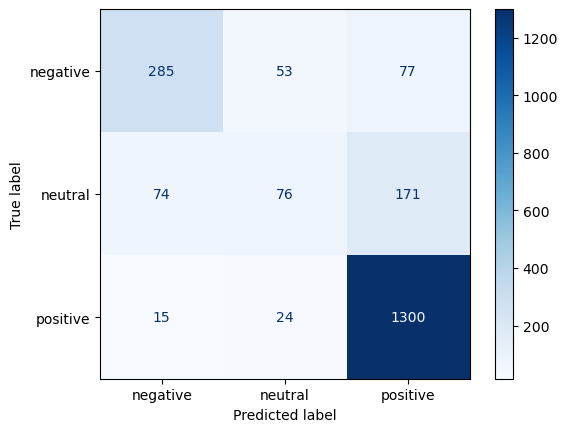

In [55]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
best_preds = best_model.predict(x_test)

cm = confusion_matrix(y_test, best_preds, labels=["negative","neutral","positive"])
disp = ConfusionMatrixDisplay(cm, display_labels=["negative","neutral","positive"])
disp.plot(cmap="Blues");

### Sentiment Analysis

In [57]:
from textblob import TextBlob

df[["polarity", "subjectivity"]] = df["text"].apply(lambda x: TextBlob("".join(x)).sentiment).apply(pd.Series)

In [58]:
df.sample(8)

,stars,text,sentiment,polarity,subjectivity
7839,5,best buffet strip hand huge select meat seafoo...,positive,0.366667,0.523611
8352,4,came lunch base review onlin disappoint mainli...,positive,0.300000,0.837500
8902,5,best food best best servic best francesico tha...,positive,1.000000,0.300000
8161,5,pricey ye think worth price want ultim vega bu...,positive,0.037179,0.502308
11,5,tri bacchan lunch wednesday parti adult yo yo ...,positive,0.280000,0.520000
7558,3,dark food eat love pictur food social media li...,neutral,0.141026,0.483333
10273,5,heard thi buffet wa vega knew thi place wa pri...,positive,-0.045000,0.255000
5393,5,servic staff attent star plate taken immedi wa...,positive,0.491667,0.916667


In [59]:
df[["polarity", "subjectivity"]].describe().T

,count,mean,std,min,25%,50%,75%,max
polarity,10375.0,0.284286,0.235700,-1.0,0.141115,0.268816,0.416667,1.0
subjectivity,10375.0,0.486021,0.161762,0.0,0.400505,0.500000,0.583333,1.0


Calculating Pos, Neg, Neu, Compound - sosyal medya ve kısa cümlelerdeki duyguları yakalamada güçlüdür. Neg/Neu/Pos skorlarının yanı sıra **compound** skoru, metnin genel tonunu tek bir sayıyla özetler.

In [61]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\OguzToy\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [62]:
sia = SentimentIntensityAnalyzer()

In [63]:
df_scores = x.apply(lambda text: sia.polarity_scores(text)).apply(pd.Series)
df = pd.concat([df, df_scores], axis=1)

In [64]:
df.sample(7)

,stars,text,sentiment,polarity,subjectivity,neg,neu,pos,compound
6335,3,bacchan buffet caesar bill best buffet vega pr...,neutral,0.295000,0.425000,0.044,0.785,0.171,0.8555
4895,5,bacchan best high end buffet someon els told w...,positive,0.572000,0.368000,0.000,0.601,0.399,0.9062
4141,3,brunch wynn luxor excalibur mgm palm thi wa ex...,neutral,0.183333,0.380000,0.000,0.836,0.164,0.5994
3279,2,understand life whi thi buffet buffet befor re...,negative,0.090312,0.461250,0.000,0.867,0.133,0.8074
4012,2,atmospher nice present uniqu refresh food hand...,negative,0.210648,0.476389,0.046,0.643,0.311,0.9859
1446,5,pay pricey buffet strip definit worth wait bad...,positive,0.306667,0.746667,0.096,0.587,0.317,0.8834
8676,4,buffet brunch wa okay wa bit disappoint becaus...,positive,0.500000,0.522222,0.067,0.573,0.360,0.9682


### WordCloud

In [66]:
df=dff # ekleri kaldırılmamış kelimeleri kullanmak için önceden kopyaladığım dff yi kullanıyoruz

In [67]:
#pip install wordcloud

In [68]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [69]:
cloud_mask = np.array(Image.open("cloud.png"))

#### Star 5 and Star 1 - WORDCLOUD

In [71]:
wc_5 = WordCloud(width=500, height=350, background_color='white', mask=cloud_mask).generate(" ".join(df[df["stars"]==5]["text"]))
wc_1 = WordCloud(width=500, height=350, background_color='red', mask=cloud_mask).generate(" ".join(df[df["stars"]==1]["text"]))

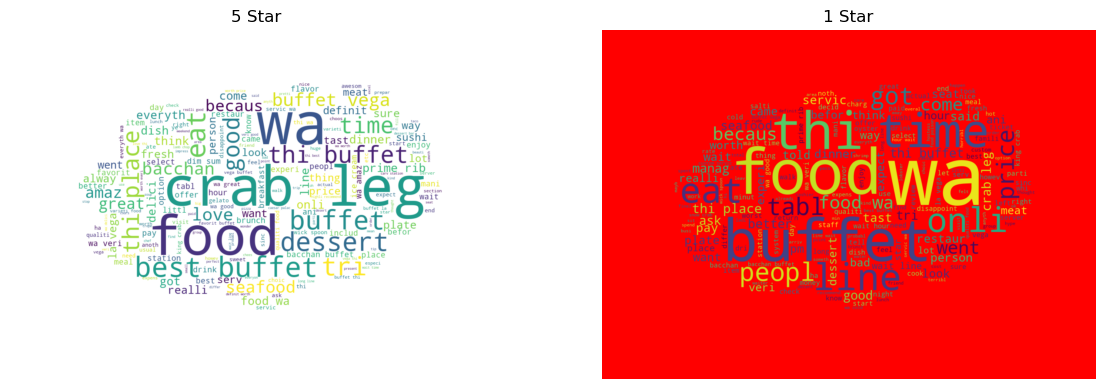

In [72]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(wc_5, interpolation='bilinear')
ax[0].axis("off")
ax[0].set_title("5 Star")

ax[1].imshow(wc_1, interpolation='bilinear')
ax[1].axis("off")
ax[1].set_title("1 Star");

#### Positive and Negative - WORDCLOUD

In [74]:
wc_pos = WordCloud(width=500, height=350, background_color='white', mask=cloud_mask).generate(" ".join(df[df["sentiment"] == "positive"]["text"]))
wc_neg = WordCloud(width=500, height=350, background_color='red', mask=cloud_mask).generate(" ".join(df[df["sentiment"] == "negative"]["text"]))

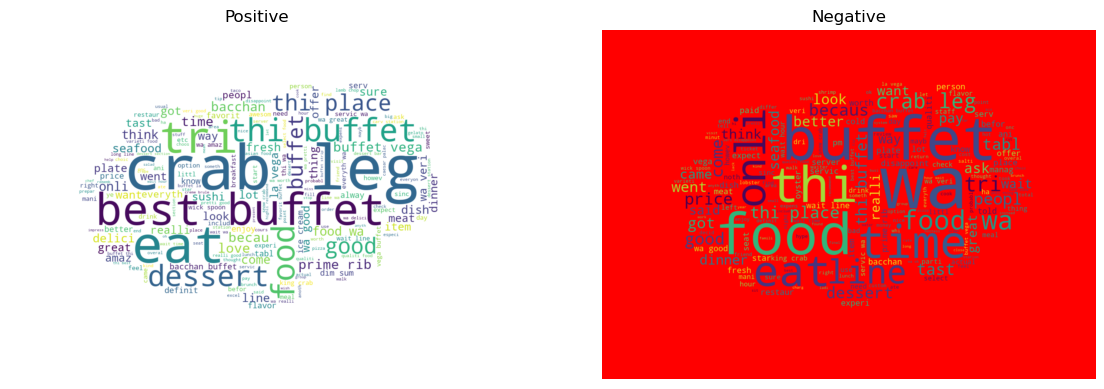

In [75]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(wc_pos, interpolation='bilinear')
ax[0].axis("off")
ax[0].set_title("Positive")

ax[1].imshow(wc_neg, interpolation='bilinear')
ax[1].axis("off")
ax[1].set_title("Negative");

### En Sık 2‑3 Kelimelik İfadeler (N‑gram)m

In [77]:
def top_ngrams(corpus, ngram_range=(2,2), n=15):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words=None)
    X = vec.fit_transform(corpus)
    freqs = zip(vec.get_feature_names_out(), X.sum(axis=0).tolist()[0])
    return sorted(freqs, key=lambda x: x[1], reverse=True)[:n]

pos_2 = top_ngrams(df[df["sentiment"] == "positive"]["text"], (2,2))
neg_2 = top_ngrams(df[df["sentiment"] == "negative"]["text"], (2,2))
pos_3 = top_ngrams(df[df["sentiment"] == "positive"]["text"], (3,3))
neg_3 = top_ngrams(df[df["sentiment"] == "negative"]["text"], (3,3))

print("Positive 2‑grams:", pos_2)
print("Negative 2‑grams:", neg_2)
print("Positive 3‑grams:", pos_3)
print("Negative 3‑grams:", neg_3)

Positive 2‑grams: [('crab leg', 2548), ('best buffet', 1609), ('thi buffet', 1595), ('thi place', 1516), ('buffet vega', 1217), ('prime rib', 1147), ('food wa', 984), ('wa good', 742), ('la vega', 710), ('wa veri', 670), ('bacchan buffet', 630), ('dim sum', 628), ('ice cream', 569), ('wick spoon', 558), ('king crab', 527)]
Negative 2‑grams: [('crab leg', 577), ('food wa', 576), ('thi place', 556), ('thi buffet', 480), ('wa good', 279), ('prime rib', 266), ('wait line', 241), ('king crab', 225), ('wa veri', 217), ('wait hour', 194), ('thi wa', 182), ('buffet wa', 176), ('servic wa', 174), ('wick spoon', 173), ('buffet vega', 166)]
Positive 3‑grams: [('best buffet vega', 558), ('king crab leg', 330), ('buffet la vega', 321), ('prime rib wa', 176), ('snow crab leg', 170), ('thi best buffet', 170), ('best buffet la', 166), ('steam crab leg', 146), ('wa pretti good', 143), ('worth everi penni', 141), ('thi buffet wa', 132), ('mochi ice cream', 131), ('wa veri good', 130), ('crab leg oyster'

- Bazı ifadeler hem pozitif hem de negatif te ortak olarak çokca kullanılmış, bu yüzden ortak ifadeler olmayan ifadeleri seçiyoruz ve görselleştiriyoruz

In [79]:
def get_unique_top_ngrams(pos_list, neg_list, top_n=15):
    pos_set = set(x[0] for x in pos_list)
    neg_set = set(x[0] for x in neg_list)
    unique_pos = [x for x in pos_list if x[0] not in neg_set][:top_n]
    unique_neg = [x for x in neg_list if x[0] not in pos_set][:top_n]
    return unique_pos, unique_neg
def plot_ngrams(ngrams, title, color):
    labels, counts = zip(*ngrams)
    plt.barh(labels, counts, color=color)
    plt.title(title)
    plt.xlabel("Frequency")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [80]:
uniq_pos_2, uniq_neg_2 = get_unique_top_ngrams(pos_2, neg_2)
uniq_pos_3, uniq_neg_3 = get_unique_top_ngrams(pos_3, neg_3)

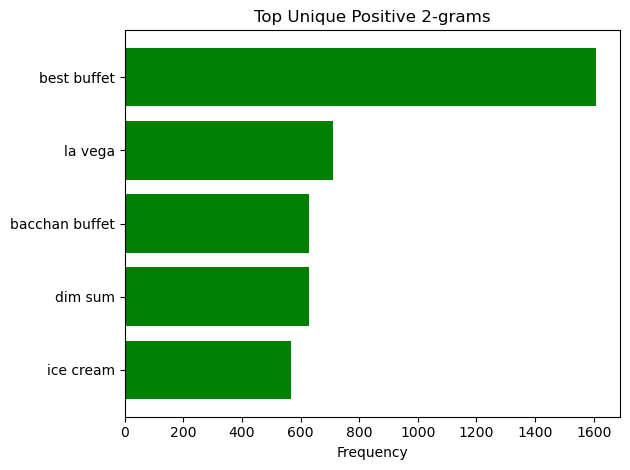

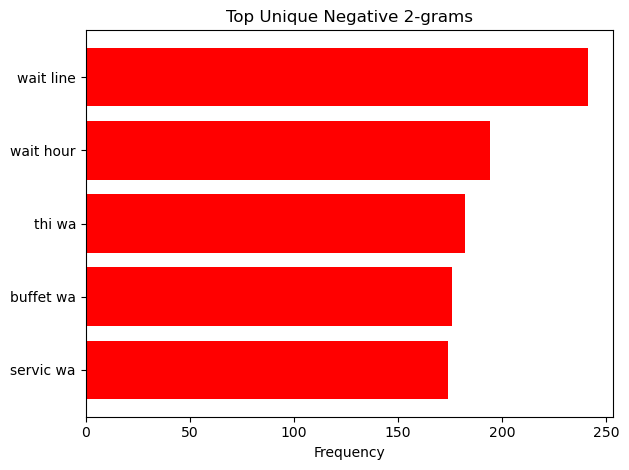

In [81]:
plot_ngrams(uniq_pos_2, "Top Unique Positive 2-grams", "green")
plot_ngrams(uniq_neg_2, "Top Unique Negative 2-grams", "red")

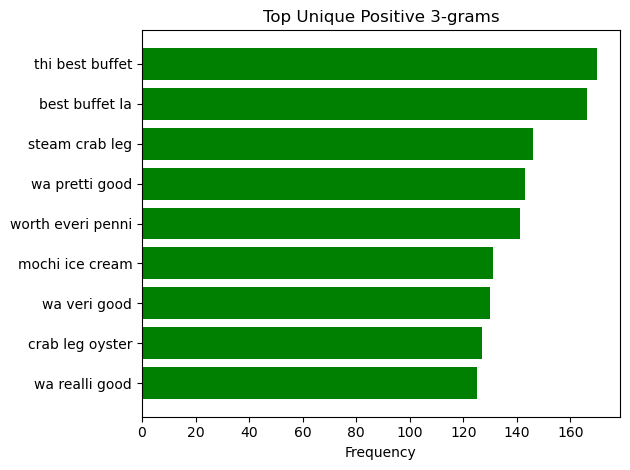

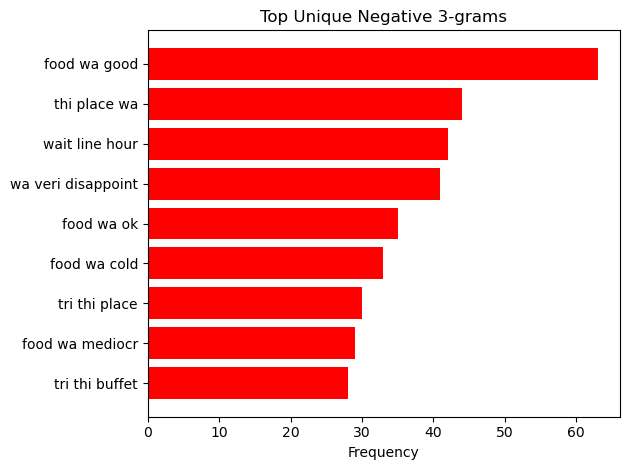

In [82]:
plot_ngrams(uniq_pos_3, "Top Unique Positive 3-grams", "green")
plot_ngrams(uniq_neg_3, "Top Unique Negative 3-grams", "red")

Aynı şeyi WordCloud için yapıyoruz

In [84]:
# Ortak olmayan kelimeleri çıkar
positive_text = " ".join(df[df["sentiment"] == "positive"]["text"])
negative_text = " ".join(df[df["sentiment"] == "negative"]["text"])

positive_words = set(positive_text.split())
negative_words = set(negative_text.split())

unique_positive = " ".join(positive_words - negative_words)
unique_negative = " ".join(negative_words - positive_words)

wc_pos = WordCloud(width=500, height=350, background_color='white', mask=cloud_mask).generate(unique_positive)
wc_neg = WordCloud(width=500, height=350, background_color='red', mask=cloud_mask).generate(unique_negative)

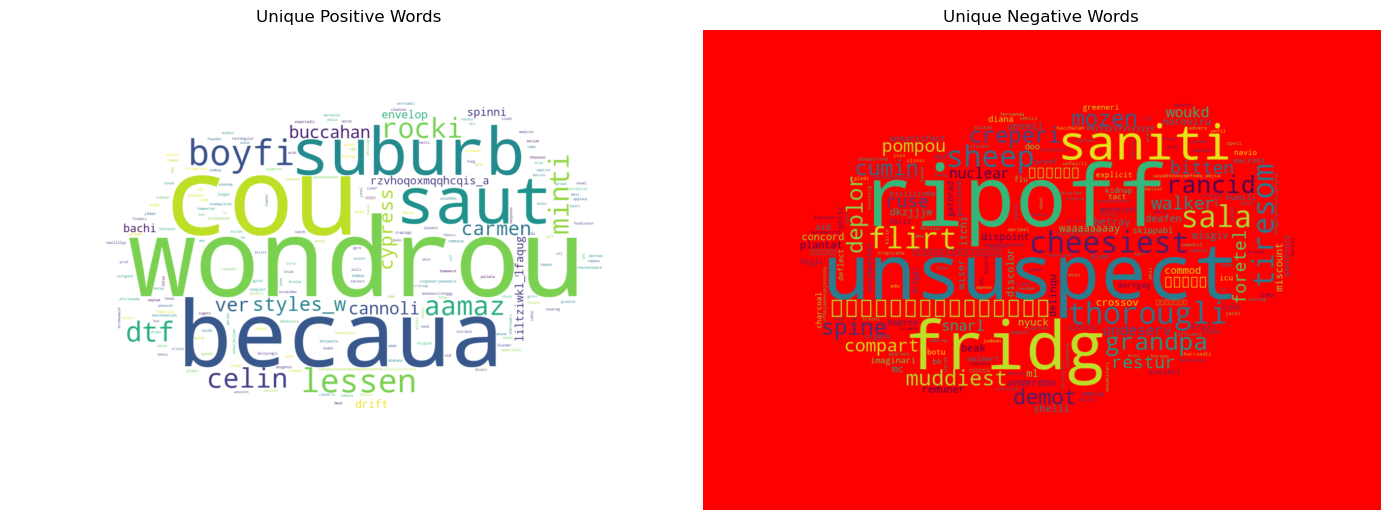

In [85]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].imshow(wc_pos, interpolation='bilinear')
ax[0].axis("off")
ax[0].set_title("Unique Positive Words")

ax[1].imshow(wc_neg, interpolation='bilinear')
ax[1].axis("off")
ax[1].set_title("Unique Negative Words")

plt.tight_layout()
plt.show()